In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = Path("..") / "data" / "olist.db"
conn = sqlite3.connect(DB_PATH)

In [2]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time'
        ELSE 'Repeat'
    END AS segment,
    COUNT(*) AS customers
FROM customer_orders
GROUP BY segment;
"""

segments = pd.read_sql(query, conn)
segments



,segment,customers
0,One-time,90557
1,Repeat,2801


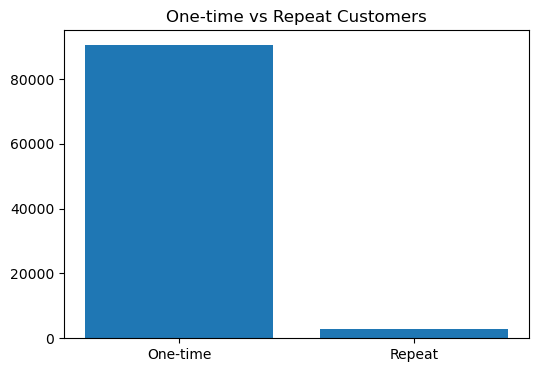

In [3]:
plt.figure(figsize=(6,4))
plt.bar(segments["segment"], segments["customers"])
plt.title("One-time vs Repeat Customers")
plt.show()

In [4]:
query = """
SELECT
    c.customer_unique_id,
    SUM(oi.price + oi.freight_value) AS total_spend
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY total_spend DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)
top_customers

,customer_unique_id,total_spend
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31
4,459bef486812aa25204be022145caa62,6922.21
5,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
6,4007669dec559734d6f53e029e360987,6081.54
7,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34
8,48e1ac109decbb87765a3eade6854098,4681.78
9,c8460e4251689ba205045f3ea17884a1,4655.88
